# Notebook 05 - TabTransformer

## TabTransformer Model Overview

This notebook trains the most advanced model in the project. The TabTransformer represents categorical and numerical features as tokens and uses self-attention to learn relationships between them.

The goal is to improve Macro F1 and minority-class detection, especially for the Long delay class.


In [1]:
from pathlib import Path
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

## Environment and Reproducibility

This section sets random seeds, project paths, output folders, and the compute device. These settings make the experiment easier to reproduce.


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

BASE_DIR = Path.cwd().parent

PROCESSED_DIR = BASE_DIR / "data" / "generated" / "processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Data and Metadata Loading

We load the same feature metadata, category sizes, class names, and class weights used by the previous models. This keeps the model comparison consistent.


In [3]:
with open(PROCESSED_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

with open(PROCESSED_DIR / "category_cardinalities.json", "r") as f:
    category_cardinalities = json.load(f)

with open(PROCESSED_DIR / "class_weights.json", "r") as f:
    class_weights_dict = json.load(f)

categorical_cols = metadata["categorical_cols"]
numeric_cols = metadata["numeric_cols"]
num_classes = metadata["num_classes"]
class_names = metadata["class_names"]

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numeric_cols)
print("Num classes:", num_classes)
print("Class names:", class_names)
print("Class weights:", class_weights_dict)

assert num_classes == 3
assert set(class_names.keys()) == {"0", "1", "2"}
assert set(class_weights_dict.keys()) == {"0", "1", "2"}

print("Metadata validation passed.")

Categorical columns: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'ORIGIN_STATE_ABR', 'DEST', 'DEST_STATE_ABR', 'ROUTE', 'DEP_TIME_BLK', 'ARR_TIME_BLK']
Numerical columns: ['DISTANCE', 'CRS_DEP_MINUTES_OF_DAY', 'dep_time_sin', 'dep_time_cos', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'is_weekend']
Num classes: 3
Class names: {'0': 'On time', '1': 'Delay', '2': 'Long delay'}
Class weights: {'0': 0.4195488529623715, '1': 2.0804489830682193, '2': 7.3625845179253355}
Metadata validation passed.


The processed train, validation, and test arrays are loaded from the `.npz` files. These arrays were created with a stratified random split from Notebook 02.

In [4]:
train_data = np.load(PROCESSED_DIR / "train_data.npz")
val_data = np.load(PROCESSED_DIR / "val_data.npz")
test_data = np.load(PROCESSED_DIR / "test_data.npz")

X_train_cat = train_data["X_cat"]
X_train_num = train_data["X_num"]
y_train = train_data["y"]

X_val_cat = val_data["X_cat"]
X_val_num = val_data["X_num"]
y_val = val_data["y"]

X_test_cat = test_data["X_cat"]
X_test_num = test_data["X_num"]
y_test = test_data["y"]

print("Train categorical:", X_train_cat.shape)
print("Train numerical:", X_train_num.shape)
print("Train target:", y_train.shape)

print("Validation categorical:", X_val_cat.shape)
print("Validation numerical:", X_val_num.shape)
print("Validation target:", y_val.shape)

print("Test categorical:", X_test_cat.shape)
print("Test numerical:", X_test_num.shape)
print("Test target:", y_test.shape)

Train categorical: (14411707, 8)
Train numerical: (14411707, 9)
Train target: (14411707,)
Validation categorical: (3088223, 8)
Validation numerical: (3088223, 9)
Validation target: (3088223,)
Test categorical: (3088224, 8)
Test numerical: (3088224, 9)
Test target: (3088224,)


The PyTorch dataset and DataLoaders prepare the arrays for mini-batch training and evaluation.


In [5]:
class FlightDelayDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.as_tensor(X_cat, dtype=torch.long)
        self.X_num = torch.as_tensor(X_num, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

In [6]:
batch_size = 4096

train_dataset = FlightDelayDataset(X_train_cat, X_train_num, y_train)
val_dataset = FlightDelayDataset(X_val_cat, X_val_num, y_val)
test_dataset = FlightDelayDataset(X_test_cat, X_test_num, y_test)

class_counts = np.bincount(y_train, minlength=num_classes)
class_percentages = class_counts / class_counts.sum() * 100

print("Class counts:", class_counts)
print("Class percentages:", np.round(class_percentages, 4))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Class counts: [11450162  2309070   652475]
Class percentages: [79.4504 16.0222  4.5274]
Train batches: 3519
Validation batches: 754
Test batches: 754


## Token-Based Feature Representation

Each categorical feature has its own embedding table. Numerical features are also projected into token representations so they can be processed with the categorical tokens.


In [7]:
categorical_cardinalities = [
    int(category_cardinalities[col])
    for col in categorical_cols
]

print("Categorical cardinalities:")
for col, card in zip(categorical_cols, categorical_cardinalities):
    print(col, card)

Categorical cardinalities:
OP_UNIQUE_CARRIER 16
ORIGIN 363
ORIGIN_STATE_ABR 53
DEST 363
DEST_STATE_ABR 53
ROUTE 7454
DEP_TIME_BLK 20
ARR_TIME_BLK 20


## Transformer Encoder Architecture

The model adds a CLS token to summarize the feature tokens. The Transformer Encoder uses self-attention to learn relationships between airline, route, airport, time, and distance features.


In [8]:
class TabTransformerModel(nn.Module):
    def __init__(
        self,
        categorical_cardinalities,
        num_numeric_features,
        num_classes,
        d_model=96,
        n_heads=6,
        n_layers=4,
        ff_dim=384,
        transformer_dropout=0.12,
        head_hidden_dims=[384, 192],
        head_dropout=0.20
    ):
        super().__init__()

        self.num_categorical_features = len(categorical_cardinalities)
        self.num_numeric_features = num_numeric_features
        self.d_model = d_model

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cardinality, d_model)
            for cardinality in categorical_cardinalities
        ])

        self.cat_column_embeddings = nn.Parameter(
            torch.randn(self.num_categorical_features, d_model) * 0.02
        )

        self.num_column_embeddings = nn.Parameter(
            torch.randn(num_numeric_features, d_model) * 0.02
        )

        self.num_weight = nn.Parameter(
            torch.randn(num_numeric_features, d_model) * 0.02
        )

        self.num_bias = nn.Parameter(
            torch.zeros(num_numeric_features, d_model)
        )

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, d_model) * 0.02
        )

        self.input_norm = nn.LayerNorm(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=transformer_dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        head_input_dim = (2 * d_model) + num_numeric_features

        head_layers = []
        input_dim = head_input_dim

        for hidden_dim in head_hidden_dims:
            head_layers.append(nn.LayerNorm(input_dim))
            head_layers.append(nn.Linear(input_dim, hidden_dim))
            head_layers.append(nn.GELU())
            head_layers.append(nn.Dropout(head_dropout))
            input_dim = hidden_dim

        head_layers.append(nn.LayerNorm(input_dim))
        head_layers.append(nn.Linear(input_dim, num_classes))

        self.head = nn.Sequential(*head_layers)

    def forward(self, x_cat, x_num):
        batch_size = x_cat.size(0)

        cat_tokens = []

        for i, embedding_layer in enumerate(self.cat_embeddings):
            token = embedding_layer(x_cat[:, i])
            token = token + self.cat_column_embeddings[i]
            cat_tokens.append(token.unsqueeze(1))

        cat_tokens = torch.cat(cat_tokens, dim=1)

        num_tokens = (
            x_num.unsqueeze(-1) * self.num_weight.unsqueeze(0)
            + self.num_bias.unsqueeze(0)
            + self.num_column_embeddings.unsqueeze(0)
        )

        cls_token = self.cls_token.expand(batch_size, -1, -1)

        tokens = torch.cat(
            [cls_token, cat_tokens, num_tokens],
            dim=1
        )

        tokens = self.input_norm(tokens)

        encoded_tokens = self.transformer(tokens)

        cls_output = encoded_tokens[:, 0, :]

        mean_output = encoded_tokens[:, 1:, :].mean(dim=1)

        head_input = torch.cat(
            [cls_output, mean_output, x_num],
            dim=1
        )

        logits = self.head(head_input)

        return logits

In [9]:
model_config = {
    "d_model": 96,
    "n_heads": 6,
    "n_layers": 4,
    "ff_dim": 384,
    "transformer_dropout": 0.12,
    "head_hidden_dims": [384, 192],
    "head_dropout": 0.20
}

model = TabTransformerModel(
    categorical_cardinalities=categorical_cardinalities,
    num_numeric_features=len(numeric_cols),
    num_classes=num_classes,
    **model_config
).to(device)

model

c:\Users\of_de\anaconda3\envs\dl_project\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


TabTransformerModel(
  (cat_embeddings): ModuleList(
    (0): Embedding(16, 96)
    (1): Embedding(363, 96)
    (2): Embedding(53, 96)
    (3): Embedding(363, 96)
    (4): Embedding(53, 96)
    (5): Embedding(7454, 96)
    (6-7): 2 x Embedding(20, 96)
  )
  (input_norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
        )
        (linear1): Linear(in_features=96, out_features=384, bias=True)
        (dropout): Dropout(p=0.12, inplace=False)
        (linear2): Linear(in_features=384, out_features=96, bias=True)
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.12, inplace=False)
        (dropout2): Dropout(p=0.12, in

In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 1405461
Trainable parameters: 1405461


## Training Configuration

The loss function uses class weights and label smoothing. The optimizer is AdamW, and OneCycleLR adjusts the learning rate during training.


In [11]:
raw_class_weights = np.array(
    [class_weights_dict[str(i)] for i in range(num_classes)],
    dtype=np.float32
)

print("Raw class weights:", raw_class_weights)

class_weights = np.power(raw_class_weights, 0.60)
class_weights = np.clip(class_weights, 0.45, 2.75)
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Final class weights:", class_weights_tensor)

Raw class weights: [0.41954884 2.0804489  7.3625846 ]
Final class weights: tensor([0.3639, 0.9510, 1.6851], device='cuda:0')


## Mixed Precision Training

Automatic mixed precision is used when CUDA is available. This can speed up training and reduce GPU memory use while keeping the training process stable.


In [12]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.01
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=6e-4,
    weight_decay=1e-4
)

num_epochs = 12

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=6e-4,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.12,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=100
)

use_amp = torch.cuda.is_available()

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print("Using AMP:", use_amp)

Using AMP: True


C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\1761823827.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


In [13]:
def print_prediction_distribution(predictions, title="Prediction Distribution"):
    unique, counts = np.unique(predictions, return_counts=True)

    distribution = {
        int(k): int(v)
        for k, v in zip(unique, counts)
    }

    print(title)
    print(distribution)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

Gradient clipping is included in the training step to avoid very large updates. This is useful for a Transformer-based model trained on a large dataset.


In [14]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    scheduler,
    scaler,
    device,
    epoch=None,
    num_epochs=None,
    max_grad_norm=1.0
):
    model.train()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Training Epoch {epoch}/{num_epochs}",
        leave=True
    )

    for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
        x_cat = x_cat.to(device, non_blocking=True)
        x_num = x_num.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(x_cat, x_num)
            loss = criterion(outputs, y)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()

        batch_size_actual = y.size(0)
        processed_samples += batch_size_actual
        total_loss += loss.item() * batch_size_actual

        preds = torch.argmax(outputs.detach(), dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y.detach().cpu().numpy())

        current_loss = total_loss / processed_samples
        current_progress = (processed_samples / len(dataloader.dataset)) * 100
        current_lr = scheduler.get_last_lr()[0]

        progress_bar.set_postfix({
            "progress": f"{current_progress:.2f}%",
            "loss": f"{loss.item():.4f}",
            "avg_loss": f"{current_loss:.4f}",
            "lr": f"{current_lr:.6f}"
        })

    avg_loss = total_loss / len(dataloader.dataset)

    metrics = compute_metrics(
        np.array(all_targets),
        np.array(all_preds)
    )

    return avg_loss, metrics

In [15]:
def evaluate_model(model, dataloader, criterion, device, split_name="Validation"):
    model.eval()

    total_loss = 0
    all_preds = []
    all_targets = []
    processed_samples = 0

    progress_bar = tqdm(
        dataloader,
        desc=f"Evaluating {split_name}",
        leave=True
    )

    with torch.no_grad():
        for batch_idx, (x_cat, x_num, y) in enumerate(progress_bar):
            x_cat = x_cat.to(device, non_blocking=True)
            x_num = x_num.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(x_cat, x_num)
                loss = criterion(outputs, y)

            batch_size_actual = y.size(0)
            processed_samples += batch_size_actual
            total_loss += loss.item() * batch_size_actual

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y.cpu().numpy())

            current_loss = total_loss / processed_samples
            current_progress = (processed_samples / len(dataloader.dataset)) * 100

            progress_bar.set_postfix({
                "progress": f"{current_progress:.2f}%",
                "avg_loss": f"{current_loss:.4f}"
            })

    avg_loss = total_loss / len(dataloader.dataset)

    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)

    metrics = compute_metrics(y_true, y_pred)

    return avg_loss, metrics, y_true, y_pred

## Training and Early Stopping

The model is trained with validation monitoring and early stopping. The checkpoint with the best validation Macro F1 is saved for final evaluation.


In [16]:
best_val_macro_f1 = 0
best_model_path = MODELS_DIR / "tabtransformer_best.pt"

patience = 5
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(1, num_epochs + 1):
    epoch_start = time.time()

    print(f"\nStarting epoch {epoch}/{num_epochs}")
    print("-" * 100)

    train_loss, train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=device,
        epoch=epoch,
        num_epochs=num_epochs,
        max_grad_norm=1.0
    )

    val_loss, val_metrics, y_true_val, y_pred_val = evaluate_model(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
        split_name="Validation"
    )

    print_prediction_distribution(
        y_pred_val,
        "Validation Prediction Distribution"
    )

    epoch_time = time.time() - epoch_start

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "epoch_time_seconds": epoch_time
    })

    print(f"\nEpoch {epoch}/{num_epochs} completed")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Train Bal Acc: {train_metrics['balanced_accuracy']:.4f} | "
        f"Train Macro F1: {train_metrics['macro_f1']:.4f} | "
        f"Train Weighted F1: {train_metrics['weighted_f1']:.4f}"
    )
    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_metrics['accuracy']:.4f} | "
        f"Val Bal Acc:   {val_metrics['balanced_accuracy']:.4f} | "
        f"Val Macro F1:   {val_metrics['macro_f1']:.4f} | "
        f"Val Weighted F1:   {val_metrics['weighted_f1']:.4f}"
    )
    print(f"Epoch time: {epoch_time:.2f} seconds")
    print("-" * 100)

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        epochs_without_improvement = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "categorical_cardinalities": categorical_cardinalities,
            "numeric_cols": numeric_cols,
            "categorical_cols": categorical_cols,
            "num_classes": num_classes,
            "best_val_macro_f1": best_val_macro_f1,
            "epoch": epoch,
            "model_config": model_config,
            "class_weights": class_weights.tolist(),
            "batch_size": batch_size,
            "loss_function": "CrossEntropyLoss with softened class weights and label smoothing",
            "optimizer": "AdamW",
            "learning_rate": 6e-4,
            "weight_decay": 1e-4,
            "pooling_strategy": "CLS token + mean token pooling"
        }, best_model_path)

        print(f"Best model saved with Val Macro F1: {best_val_macro_f1:.4f}")

    else:
        epochs_without_improvement += 1

        print(f"No improvement for {epochs_without_improvement} epoch(s)")

        if epochs_without_improvement >= patience:
            print("Early stopping triggered")
            break

total_training_time = time.time() - start_time

print("\nTraining completed")
print(f"Total training time: {total_training_time:.2f} seconds")
print(f"Best validation Macro F1: {best_val_macro_f1:.4f}")


Starting epoch 1/12
----------------------------------------------------------------------------------------------------


Training Epoch 1/12:   0%|          | 0/3519 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3846375851.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation:   0%|          | 0/754 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3111925320.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation: 100%|██████████| 754/754 [01:04<00:00, 11.68it/s, progress=100.00%, avg_loss=0.9305]


Validation Prediction Distribution
{0: 2755324, 1: 331061, 2: 1838}

Epoch 1/12 completed
Train Loss: 0.9392 | Train Acc: 0.7588 | Train Bal Acc: 0.3795 | Train Macro F1: 0.3825 | Train Weighted F1: 0.7267
Val Loss:   0.9305 | Val Acc:   0.7664 | Val Bal Acc:   0.3789 | Val Macro F1:   0.3763 | Val Weighted F1:   0.7309
Epoch time: 899.27 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.3763

Starting epoch 2/12
----------------------------------------------------------------------------------------------------


Training Epoch 2/12:   0%|          | 0/3519 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3846375851.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation:   0%|          | 0/754 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3111925320.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation: 100%|██████████| 754/754 [01:02<00:00, 12.07it/s, progress=100.00%, avg_loss=0.9243]


Validation Prediction Distribution
{0: 2643726, 1: 405417, 2: 39080}

Epoch 2/12 completed
Train Loss: 0.9278 | Train Acc: 0.7559 | Train Bal Acc: 0.3912 | Train Macro F1: 0.3963 | Train Weighted F1: 0.7304
Val Loss:   0.9243 | Val Acc:   0.7527 | Val Bal Acc:   0.3995 | Val Macro F1:   0.4067 | Val Weighted F1:   0.7316
Epoch time: 868.15 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.4067

Starting epoch 3/12
----------------------------------------------------------------------------------------------------


...

Validation Prediction Distribution
{0: 2532909, 1: 457336, 2: 97978}

Epoch 10/12 completed
Train Loss: 0.9112 | Train Acc: 0.7515 | Train Bal Acc: 0.4127 | Train Macro F1: 0.4226 | Train Weighted F1: 0.7344
Val Loss:   0.9178 | Val Acc:   0.7379 | Val Bal Acc:   0.4235 | Val Macro F1:   0.4299 | Val Weighted F1:   0.7298
Epoch time: 881.57 seconds
----------------------------------------------------------------------------------------------------
No improvement for 1 epoch(s)

Starting epoch 11/12
----------------------------------------------------------------------------------------------------


Training Epoch 11/12:   0%|          | 0/3519 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3846375851.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation:   0%|          | 0/754 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3111925320.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation: 100%|██████████| 754/754 [01:03<00:00, 11.88it/s, progress=100.00%, avg_loss=0.9178]


Validation Prediction Distribution
{0: 2512100, 1: 471053, 2: 105070}

Epoch 11/12 completed
Train Loss: 0.9103 | Train Acc: 0.7514 | Train Bal Acc: 0.4133 | Train Macro F1: 0.4234 | Train Weighted F1: 0.7346
Val Loss:   0.9178 | Val Acc:   0.7345 | Val Bal Acc:   0.4262 | Val Macro F1:   0.4314 | Val Weighted F1:   0.7285
Epoch time: 881.45 seconds
----------------------------------------------------------------------------------------------------
Best model saved with Val Macro F1: 0.4314

Starting epoch 12/12
----------------------------------------------------------------------------------------------------


Training Epoch 12/12:   0%|          | 0/3519 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3846375851.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation:   0%|          | 0/754 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\3111925320.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating Validation: 100%|██████████| 754/754 [01:04<00:00, 11.73it/s, progress=100.00%, avg_loss=0.9180]


Validation Prediction Distribution
{0: 2517248, 1: 467548, 2: 103427}

Epoch 12/12 completed
Train Loss: 0.9099 | Train Acc: 0.7515 | Train Bal Acc: 0.4140 | Train Macro F1: 0.4242 | Train Weighted F1: 0.7347
Val Loss:   0.9180 | Val Acc:   0.7354 | Val Bal Acc:   0.4256 | Val Macro F1:   0.4311 | Val Weighted F1:   0.7288
Epoch time: 892.85 seconds
----------------------------------------------------------------------------------------------------
No improvement for 1 epoch(s)

Training completed
Total training time: 10531.42 seconds
Best validation Macro F1: 0.4314


Training history is saved and plotted for loss, Macro F1, and balanced accuracy. These curves help check if the model is improving or overfitting.


In [17]:
history_df = pd.DataFrame(history)

history_path = RESULTS_DIR / "tabtransformer_training_history.csv"
history_df.to_csv(history_path, index=False)

history_df

,epoch,train_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,train_weighted_f1,val_loss,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,epoch_time_seconds
0,1,0.939218,0.758845,0.379533,0.382542,0.726663,0.930499,0.766428,0.378927,0.376296,0.730877,899.267255
1,2,0.927775,0.755877,0.391204,0.396342,0.730352,0.924274,0.752713,0.399453,0.406682,0.731589,868.148528
2,3,0.923884,0.754614,0.396006,0.402582,0.731374,0.925485,0.744135,0.407775,0.414504,0.729877,863.775532
3,4,0.921198,0.753832,0.399610,0.407195,0.732116,0.920751,0.739276,0.414103,0.420848,0.728857,868.020968
4,5,0.919041,0.753078,0.402621,0.410988,0.732592,0.920600,0.731153,0.421692,0.426718,0.726277,866.839221
5,6,0.917162,0.752790,0.404840,0.413700,0.733074,0.921002,0.745754,0.414325,0.423108,0.731898,866.335587
6,7,0.915442,0.752096,0.407600,0.416876,0.733482,0.918553,0.740499,0.417941,0.425403,0.730228,870.000846
7,8,0.913799,0.752079,0.409048,0.418566,0.733868,0.918029,0.736072,0.421722,0.427959,0.728829,886.108297
8,9,0.912410,0.751847,0.410746,0.420517,0.734164,0.918290,0.733732,0.426150,0.431376,0.728163,886.715486
9,10,0.911165,0.751455,0.412656,0.422632,0.734416,0.917839,0.737935,0.423534,0.429911,0.729770,881.568255


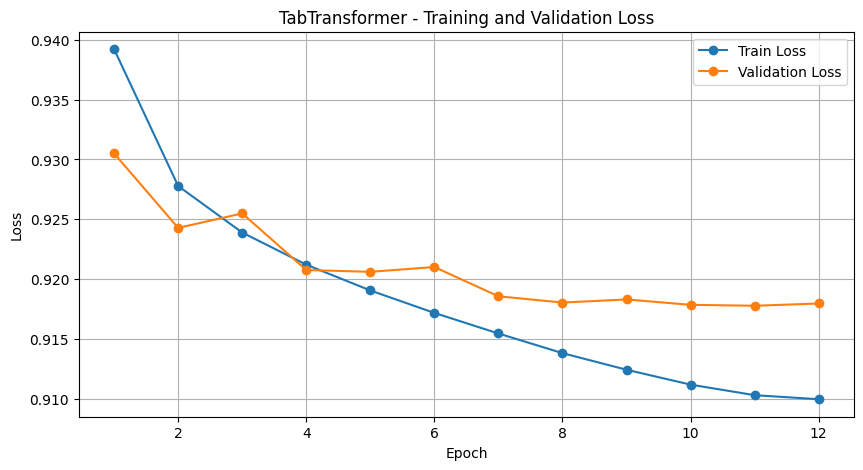

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TabTransformer - Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

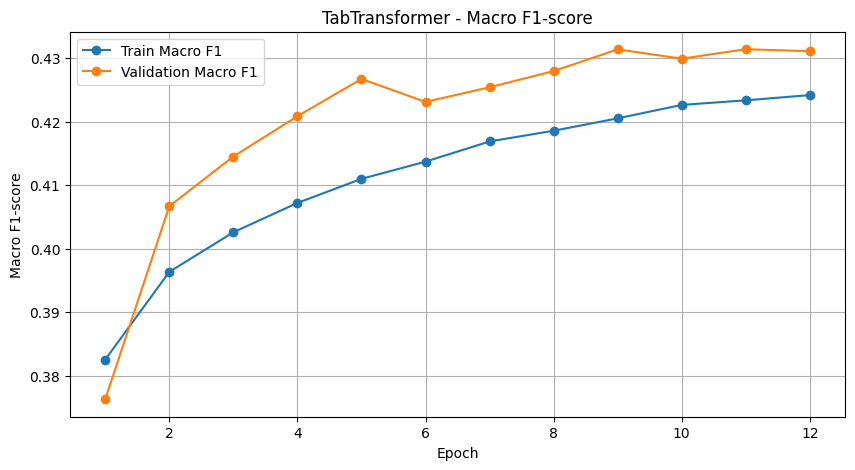

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("TabTransformer - Macro F1-score")
plt.legend()
plt.grid(True)
plt.show()

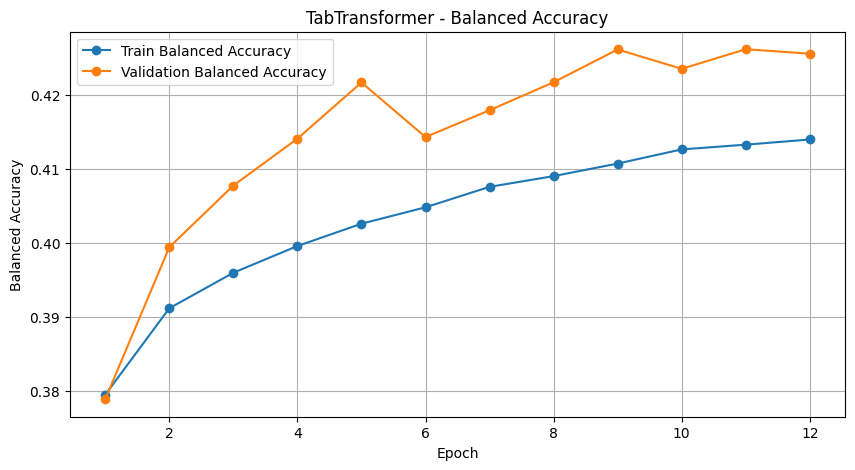

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["train_balanced_accuracy"], marker="o", label="Train Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], marker="o", label="Validation Balanced Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("TabTransformer - Balanced Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Raw Test Evaluation

The best checkpoint is loaded before generating validation and test probabilities. The raw version uses the model probabilities directly without calibration.


In [21]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = TabTransformerModel(
    categorical_cardinalities=checkpoint["categorical_cardinalities"],
    num_numeric_features=len(checkpoint["numeric_cols"]),
    num_classes=checkpoint["num_classes"],
    **checkpoint["model_config"]
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Best model loaded")
print("Best validation Macro F1:", checkpoint["best_val_macro_f1"])
print("Best epoch:", checkpoint["epoch"])

Best model loaded
Best validation Macro F1: 0.43139953125074765
Best epoch: 11


C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\2341076452.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=device

The next function returns class probabilities instead of only predicted labels. These probabilities are needed for the calibration step.


In [22]:
def predict_probabilities(model, dataloader, device, split_name="Prediction"):
    model.eval()

    all_probs = []
    all_targets = []

    progress_bar = tqdm(
        dataloader,
        desc=f"Generating probabilities - {split_name}",
        leave=True
    )

    with torch.no_grad():
        for x_cat, x_num, y in progress_bar:
            x_cat = x_cat.to(device, non_blocking=True)
            x_num = x_num.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(x_cat, x_num)
                probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_targets.extend(y.numpy())

    all_probs = np.vstack(all_probs)
    all_targets = np.array(all_targets)

    return all_targets, all_probs

In [23]:
y_val_true, val_probs = predict_probabilities(
    best_model,
    val_loader,
    device,
    split_name="Validation"
)

y_test_true, test_probs = predict_probabilities(
    best_model,
    test_loader,
    device,
    split_name="Test"
)

y_val_pred_raw = np.argmax(val_probs, axis=1)
y_test_pred_raw = np.argmax(test_probs, axis=1)

raw_val_metrics = compute_metrics(y_val_true, y_val_pred_raw)
raw_test_metrics = compute_metrics(y_test_true, y_test_pred_raw)

print("Raw validation metrics:", raw_val_metrics)
print("Raw test metrics:", raw_test_metrics)

print_prediction_distribution(
    y_test_pred_raw,
    "Raw Test Prediction Distribution"
)

Generating probabilities - Validation:   0%|          | 0/754 [00:00<?, ?it/s]C:\Users\of_de\AppData\Local\Temp\ipykernel_16492\1491797783.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Generating probabilities - Test: 100%|██████████| 754/754 [00:58<00:00, 12.86it/s]


Raw validation metrics: {'accuracy': 0.7345133431102612, 'balanced_accuracy': 0.42618066975868757, 'macro_f1': 0.43139953125074765, 'weighted_f1': 0.7284550497666193}
Raw test metrics: {'accuracy': 0.7343628570984488, 'balanced_accuracy': 0.42590774624485195, 'macro_f1': 0.4309429911984865, 'weighted_f1': 0.7283928249357083}
Raw Test Prediction Distribution
{0: 2511317, 1: 470758, 2: 106149}


## Probability Calibration

Calibration is done by tuning class probability multipliers on the validation set. This is not training on the test set, because the test labels are not used to choose the multipliers.


In [24]:
def predict_with_multipliers(probs, multipliers):
    adjusted_probs = probs * np.array(multipliers).reshape(1, -1)
    return np.argmax(adjusted_probs, axis=1)


def tune_class_multipliers(
    y_true,
    probs,
    class_1_grid=None,
    class_2_grid=None
):
    if class_1_grid is None:
        class_1_grid = np.linspace(0.60, 1.80, 31)

    if class_2_grid is None:
        class_2_grid = np.linspace(0.80, 4.00, 41)

    best_score = -1
    best_multipliers = None
    best_metrics = None

    for m1 in class_1_grid:
        for m2 in class_2_grid:
            multipliers = [1.0, float(m1), float(m2)]

            preds = predict_with_multipliers(probs, multipliers)

            score = f1_score(
                y_true,
                preds,
                average="macro",
                zero_division=0
            )

            if score > best_score:
                best_score = score
                best_multipliers = multipliers
                best_metrics = compute_metrics(y_true, preds)

    return best_multipliers, best_score, best_metrics


def fine_tune_class_multipliers(y_true, probs, base_multipliers):
    base_m1 = base_multipliers[1]
    base_m2 = base_multipliers[2]

    class_1_grid = np.linspace(
        max(0.40, base_m1 - 0.20),
        base_m1 + 0.20,
        31
    )

    class_2_grid = np.linspace(
        max(0.50, base_m2 - 0.50),
        base_m2 + 0.50,
        41
    )

    return tune_class_multipliers(
        y_true,
        probs,
        class_1_grid=class_1_grid,
        class_2_grid=class_2_grid
    )

In [25]:
coarse_multipliers, coarse_val_macro_f1, coarse_val_metrics = tune_class_multipliers(
    y_val_true,
    val_probs
)

best_multipliers, best_calibrated_val_macro_f1, calibrated_val_metrics = fine_tune_class_multipliers(
    y_val_true,
    val_probs,
    coarse_multipliers
)

print("Coarse multipliers:", coarse_multipliers)
print("Coarse validation Macro F1:", coarse_val_macro_f1)
print("Coarse validation metrics:", coarse_val_metrics)

print("\nBest fine-tuned multipliers:", best_multipliers)
print("Best calibrated validation Macro F1:", best_calibrated_val_macro_f1)
print("Calibrated validation metrics:", calibrated_val_metrics)

Coarse multipliers: [1.0, 1.1600000000000001, 1.28]
Coarse validation Macro F1: 0.43489296887625745
Coarse validation metrics: {'accuracy': 0.7065678223366642, 'balanced_accuracy': 0.44168018785657254, 'macro_f1': 0.43489296887625745, 'weighted_f1': 0.7158794357559763}

Best fine-tuned multipliers: [1.0, 1.1600000000000001, 1.3050000000000002]
Best calibrated validation Macro F1: 0.4349912732186487
Calibrated validation metrics: {'accuracy': 0.7057670381963996, 'balanced_accuracy': 0.44280159887388465, 'macro_f1': 0.4349912732186487, 'weighted_f1': 0.715484206583193}


The selected multipliers are based only on validation performance. This keeps the test set as a final, unseen evaluation split.


## Calibrated Test Evaluation

The validation-tuned multipliers are applied to the test probabilities. The calibrated version is treated as the final version because it improves class balance and Long delay detection.


In [26]:
y_test_pred_calibrated = predict_with_multipliers(
    test_probs,
    best_multipliers
)

calibrated_test_metrics = compute_metrics(
    y_test_true,
    y_test_pred_calibrated
)

print("Calibrated test metrics:")
print(calibrated_test_metrics)

print_prediction_distribution(
    y_test_pred_calibrated,
    "Calibrated Test Prediction Distribution"
)

Calibrated test metrics:
{'accuracy': 0.7057036665734092, 'balanced_accuracy': 0.4425243877048919, 'macro_f1': 0.4346130412002171, 'weighted_f1': 0.7155039689009707}
Calibrated Test Prediction Distribution
{0: 2345397, 1: 573840, 2: 168987}


The raw and calibrated classification reports are printed side by side. This makes it easier to compare the effect of calibration on each class.


In [27]:
target_names = [class_names[str(i)] for i in range(num_classes)]

raw_report = classification_report(
    y_test_true,
    y_test_pred_raw,
    target_names=target_names,
    zero_division=0
)

calibrated_report = classification_report(
    y_test_true,
    y_test_pred_calibrated,
    target_names=target_names,
    zero_division=0
)

print("RAW TEST REPORT")
print(raw_report)

print("\nCALIBRATED TEST REPORT")
print(calibrated_report)

RAW TEST REPORT
              precision    recall  f1-score   support

     On time       0.84      0.86      0.85   2453607
       Delay       0.30      0.29      0.30    494801
  Long delay       0.17      0.13      0.15    139816

    accuracy                           0.73   3088224
   macro avg       0.44      0.43      0.43   3088224
weighted avg       0.72      0.73      0.73   3088224


CALIBRATED TEST REPORT
              precision    recall  f1-score   support

     On time       0.85      0.81      0.83   2453607
       Delay       0.29      0.33      0.31    494801
  Long delay       0.15      0.18      0.17    139816

    accuracy                           0.71   3088224
   macro avg       0.43      0.44      0.43   3088224
weighted avg       0.73      0.71      0.72   3088224



The calibrated report improves Long delay recall and gives the best Macro F1 among the models in this project. Accuracy is still not the only focus because the classes are imbalanced.


In [28]:
with open(RESULTS_DIR / "tabtransformer_raw_classification_report.txt", "w") as f:
    f.write(raw_report)

with open(RESULTS_DIR / "tabtransformer_calibrated_classification_report.txt", "w") as f:
    f.write(calibrated_report)

The raw and calibrated confusion matrices show how many flights move between predicted classes after calibration.


In [29]:
raw_cm = confusion_matrix(
    y_test_true,
    y_test_pred_raw
)

calibrated_cm = confusion_matrix(
    y_test_true,
    y_test_pred_calibrated
)

raw_cm_df = pd.DataFrame(
    raw_cm,
    index=target_names,
    columns=target_names
)

calibrated_cm_df = pd.DataFrame(
    calibrated_cm,
    index=target_names,
    columns=target_names
)

raw_cm_df

,On time,Delay,Long delay
On time,2107024,288461,58122
Delay,322517,142555,29729
Long delay,81776,39742,18298


In [30]:
calibrated_cm_df

,On time,Delay,Long delay
On time,1989279,366678,97650
Delay,285070,164243,45488
Long delay,71048,42919,25849


The calibrated confusion matrix shows more Long delay predictions than the raw model. This supports using the calibrated version for the final comparison.


In [31]:
raw_cm_df.to_csv(RESULTS_DIR / "tabtransformer_raw_confusion_matrix.csv")
calibrated_cm_df.to_csv(RESULTS_DIR / "tabtransformer_calibrated_confusion_matrix.csv")

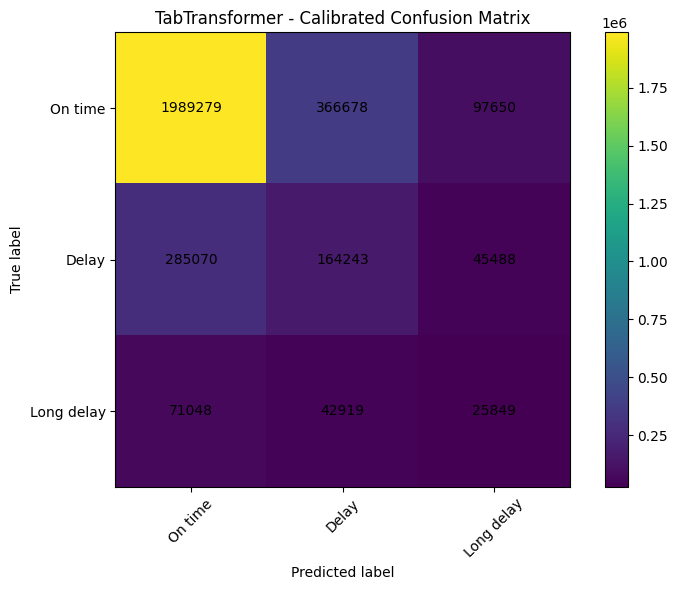

In [32]:
plt.figure(figsize=(8, 6))
plt.imshow(calibrated_cm, interpolation="nearest")
plt.title("TabTransformer - Calibrated Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(np.arange(num_classes), target_names, rotation=45)
plt.yticks(np.arange(num_classes), target_names)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, calibrated_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

The final result dictionary saves both raw and calibrated metrics, along with the model configuration and calibration multipliers.


In [33]:
tabtransformer_results = {
    "model_name": "TabTransformer / FT-Transformer Style",
    "best_val_macro_f1_raw": float(best_val_macro_f1),
    "raw_test_metrics": {
        "accuracy": float(raw_test_metrics["accuracy"]),
        "balanced_accuracy": float(raw_test_metrics["balanced_accuracy"]),
        "macro_f1": float(raw_test_metrics["macro_f1"]),
        "weighted_f1": float(raw_test_metrics["weighted_f1"])
    },
    "calibrated_validation_metrics": {
        "accuracy": float(calibrated_val_metrics["accuracy"]),
        "balanced_accuracy": float(calibrated_val_metrics["balanced_accuracy"]),
        "macro_f1": float(calibrated_val_metrics["macro_f1"]),
        "weighted_f1": float(calibrated_val_metrics["weighted_f1"])
    },
    "calibrated_test_metrics": {
        "accuracy": float(calibrated_test_metrics["accuracy"]),
        "balanced_accuracy": float(calibrated_test_metrics["balanced_accuracy"]),
        "macro_f1": float(calibrated_test_metrics["macro_f1"]),
        "weighted_f1": float(calibrated_test_metrics["weighted_f1"])
    },
    "best_multipliers": best_multipliers,
    "total_training_time_seconds": float(total_training_time),
    "num_epochs_trained": int(len(history_df)),
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "scheduler": "OneCycleLR",
    "learning_rate": 6e-4,
    "weight_decay": 1e-4,
    "loss_function": "CrossEntropyLoss with class weights and label smoothing",
    "uses_amp": bool(use_amp),
    "architecture": {
        **model_config,
        "num_numeric_features": len(numeric_cols),
        "num_categorical_features": len(categorical_cols),
        "num_classes": num_classes,
        "token_strategy": "categorical tokens + numerical tokens + CLS token",
        "pooling_strategy": "CLS token + mean token pooling",
        "calibration_strategy": "validation-tuned class probability multipliers"
    }
}

with open(RESULTS_DIR / "tabtransformer_results.json", "w") as f:
    json.dump(tabtransformer_results, f, indent=4)

tabtransformer_results

{'model_name': 'TabTransformer / FT-Transformer Style',
 'best_val_macro_f1_raw': 0.43139953125074765,
 'raw_test_metrics': {'accuracy': 0.7343628570984488,
  'balanced_accuracy': 0.42590774624485195,
  'macro_f1': 0.4309429911984865,
  'weighted_f1': 0.7283928249357083},
 'calibrated_validation_metrics': {'accuracy': 0.7057670381963996,
  'balanced_accuracy': 0.44280159887388465,
  'macro_f1': 0.4349912732186487,
  'weighted_f1': 0.715484206583193},
 'calibrated_test_metrics': {'accuracy': 0.7057036665734092,
  'balanced_accuracy': 0.4425243877048919,
  'macro_f1': 0.4346130412002171,
  'weighted_f1': 0.7155039689009707},
 'best_multipliers': [1.0, 1.1600000000000001, 1.3050000000000002],
 'total_training_time_seconds': 10531.417439460754,
 'num_epochs_trained': 12,
 'batch_size': 4096,
 'optimizer': 'AdamW',
 'scheduler': 'OneCycleLR',
 'learning_rate': 0.0006,
 'weight_decay': 0.0001,
 'loss_function': 'CrossEntropyLoss with class weights and label smoothing',
 'uses_amp': True,
 'a

In [34]:
print("Notebook 05 completed")
print("Model: TabTransformer / FT-Transformer Style")

print("\nSaved files:")
print(best_model_path)
print(RESULTS_DIR / "tabtransformer_training_history.csv")
print(RESULTS_DIR / "tabtransformer_raw_classification_report.txt")
print(RESULTS_DIR / "tabtransformer_calibrated_classification_report.txt")
print(RESULTS_DIR / "tabtransformer_raw_confusion_matrix.csv")
print(RESULTS_DIR / "tabtransformer_calibrated_confusion_matrix.csv")
print(RESULTS_DIR / "tabtransformer_results.json")

print("\nRaw Test Metrics:")
print(f"Accuracy:          {raw_test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy: {raw_test_metrics['balanced_accuracy']:.4f}")
print(f"Macro F1:          {raw_test_metrics['macro_f1']:.4f}")
print(f"Weighted F1:       {raw_test_metrics['weighted_f1']:.4f}")

print("\nCalibrated Test Metrics:")
print(f"Accuracy:          {calibrated_test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy: {calibrated_test_metrics['balanced_accuracy']:.4f}")
print(f"Macro F1:          {calibrated_test_metrics['macro_f1']:.4f}")
print(f"Weighted F1:       {calibrated_test_metrics['weighted_f1']:.4f}")

print("\nBest multipliers:")
print(best_multipliers)

Notebook 05 completed
Model: TabTransformer / FT-Transformer Style

Saved files:
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\models\tabtransformer_best.pt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_training_history.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_raw_classification_report.txt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_calibrated_classification_report.txt
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_raw_confusion_matrix.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_calibrated_confusion_matrix.csv
c:\Users\of_de\Documents\ESCUELA\UP\8vo Semestre\Deep_learning\proyecto_vuelos\results\tabtransformer_results.json

Raw Test Metrics:
Accuracy:          0.

## TabTransformer Model Conclusion

The TabTransformer is the strongest model in this project based on Macro F1. The calibrated version improves Long delay recall and gives the most balanced final comparison result, while still showing that long-delay prediction remains challenging.
